Importing my development version of ShadowGrouping

In [1]:
import sys, numpy as np, time, pickle
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
import matplotlib.pyplot as plt
from IPython.display import Image, display
from os import mkdir
from os.path import isdir

# adding ShadowGrouping package to the system path
# SG_package_path = r"G:\\My Drive\\Work\\Research\\Numerics\\ShadowGrouping Code\\"
#SG_package_path = r"C:\Users\aebad\shadowgrouping\\"
SG_package_path = r"D:\priori\\"
sys.path.insert(0, SG_package_path)
savename = "_{}_.txt" # insert {mapping_name}
savepath = "generated_data/"
# defining path where Hamiltonians are stored
folder_Hamiltonians = SG_package_path + "Hamiltonians_v2\\"

In [2]:
from shadowgrouping_v2.measurement_schemes import L1_sampler, Derandomization
from shadowgrouping.measurement_schemes import Shadow_Grouping
from shadowgrouping.measurement_schemes_Shadowupdate import (Priori, Posteriori)
from shadowgrouping_v2.weight_functions import Bernstein_bound
from shadowgrouping_v2.energy_estimator import Energy_estimator, StateSampler, Sign_estimator
from shadowgrouping_v2.helper_functions import (
    setting_to_str, char_to_int, int_to_char, settings_to_dict, prepare_settings_for_numba, gaussian_weights, gaussian_random_paulis, uniform_weights, uniform_random_paulis,
    sample_obs_from_setting, setting_to_str, setting_to_obs_form, sample_obs_batch_from_setting_batch, sample_obs_batch_from_setting_batch_numba, bootstrap_rmse)
from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state
from shadowgrouping_v2.guarantees import (
    get_epsilon_Bernstein, get_epsilon_Bernstein_no_restricted_validity, 
    get_epsilon_Bernstein_tighter, get_epsilon_Bernstein_tighter_no_restricted_validity, 
    get_epsilon_Bernstein_scalar, get_epsilon_Bernstein_scalar_no_restricted_validity,
    get_epsilon_Bernstein_scalar_tighter, get_epsilon_Bernstein_scalar_tighter_no_restricted_validity, 
    get_epsilon_Hoeffding_scalar, get_epsilon_Hoeffding_scalar_tighter, get_epsilon_Chebyshev_scalar, 
    get_epsilon_Chebyshev_scalar_tighter, get_epsilon_single_Hoeffding_plus_union_bound,
    get_epsilon_Chebyshev_scalar_numba, get_epsilon_Chebyshev_scalar_tighter_numba,
    get_epsilon_Hoeffding_scalar_numba, get_epsilon_Hoeffding_scalar_tighter_numba)
from guarantees.exact_covariances import covariance_matrix
from guarantees.guarantees import (get_epsilon_Chebyshev_scalar_tighter_numba, get_epsilon_Chebyshev_scalar_tightest_numba)

Choosing molecule, basis set and fermion-to-qubit mapping

In [3]:
molecule_name = "H2" # choose one out of the molecules ['H2', 'H2_6-31g', 'LiH', 'BeH2', 'H2O', 'NH3']
mapping_name = "JW" # choose one out of ["JW","BK","Parity"]
if molecule_name == 'H2':
    basis_set = "6-31g"
else:
    basis_set = "sto3g"
num_qubits = {'H2': 8, 'LiH': 12, 'BeH2': 14, 'H2O': 14, "NH3": 16} # number of qubits in which Hamiltonian is defined
savename = molecule_name + "_molecule_" + mapping_name + "_" + basis_set + savename

Import the original hamiltonian file

In [4]:
# ensure the folder exists
import os


assert os.path.isdir(folder_Hamiltonians), f"Path '{folder_Hamiltonians}' does not exist or is not a directory."
    # find folder matching molecule + basis name
available_folders = os.listdir(folder_Hamiltonians)
prefix = f"{molecule_name}_{basis_set}"
folder_name = None
for folder in available_folders:
    if folder.startswith(prefix):
        folder_name = folder
        break

assert folder_name is not None, f"File not found for molecule '{molecule_name}' and basis set '{basis_set}'."
full_folder_path = os.path.join(folder_Hamiltonians, folder_name)

    # look for encoding and energy file
available_files = os.listdir(full_folder_path)
    
    #print(f"full path to folder",full_folder_path)
file_name = None
file_energy = None
for file in available_files:
    if file.lower().startswith(mapping_name[:2].lower()) and "grouped" not in file:
        file_name = file
    elif file == "ExactEnergy.txt":
        file_energy = file

assert file_name is not None, f"File not found for encoding '{mapping_name}'."
assert file_energy is not None, "File not found for ground-state energy."
    
print(f"full path to file",os.path.join(full_folder_path, file_name))

full path to file D:\priori\\Hamiltonians_v2\H2_6-31g_8qubits\jw.txt


Generating random hamiltonains and sampling for ShadowGrouping and Priori

In [ ]:
Nrandom = 1
t_1 = time.time()
Nreps = 100
eps = 0.1
delta = 0.33
Nrounds = 1000
rmse_values_shadow = []
rmse_stds_shadow = []
rmse_values_priori = []
rmse_stds_priori = []
epsilonbernstein_shadow = []
epsilonbernstein_priori = []
epsilonchebyshevtighter_shadow = []
epsilonchychev_tightest_shadow = []
sanity = True
tightest = True
for i in range(Nrandom):
    print(f"Round {i+1}")
    # 1. generate random Hamiltonian
    gaussian_weights(os.path.join(full_folder_path, file_name), center=0, width=1)
    #gaussian_random_paulis(os.path.join(full_folder_path, file_name), avg_support=5.8, std_support=1.0)
    #uniform_weights(os.path.join(full_folder_path, file_name), low=-1, high=1)
    #uniform_random_paulis(os.path.join(full_folder_path, file_name), avg_support=5.8, std_support=1.0)
    # 2. Load pauli list and extract the exact ground state energy and state
    observables, w, offset, E_GS, state = load_pauli_list(folder_Hamiltonians,molecule_name,basis_set,mapping_name, verbose=False, diagonalize=True)
    if tightest:
        # Computing exact representation of full covariance matrix
        exact_covariances = covariance_matrix(state, observables)
        #print(np.round(exact_covariances,3))
        cov_real = np.ascontiguousarray(((exact_covariances + exact_covariances.conj().T).real) * 0.5, dtype=np.float64)
    if sanity:
        # Sanity check: Computing total variance using full matrix representation of Hamiltonian
        H_dot_state = apply_Hamiltonian_to_state(state, molecule_name, basis_set, mapping_name, folder_Hamiltonians)
        exp_value_H2 = np.dot(np.conjugate(H_dot_state), H_dot_state)
        exp_value_H = np.dot(np.conjugate(state), H_dot_state)
        var_H = exp_value_H2 - exp_value_H**2
        print(f"Total variance: {var_H}") # Should be zero since state is an exact eigenstate of Hamiltonian
    alpha = np.max(np.abs(w))/np.min(np.abs(w)) + np.min(np.abs(w))
    # 3. first try Shadow Grouping
    state_sampler = StateSampler(state)
    method = Shadow_Grouping(observables,w,eps,Bernstein_bound(alpha=alpha)())
    estimator = Energy_estimator(method,state_sampler,offset=offset,N_reps_exp=Nreps)
    estimator.reset()
    estimator.propose_next_settings(Nrounds)
    epsilonbernstein , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator.measurement_scheme.N_hits, w, estimator.settings_dict)
    print(f"Epsilon Bernstein for Shadow Grouping: {epsilonbernstein}")
    epsilonbernstein_shadow.append(epsilonbernstein)
    epsilonchebyshevtighter = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w)
    print(f"Epsilon Chebyshev (tighter) for Shadow Grouping: {epsilonchebyshevtighter}")
    epsilonchebyshevtighter_shadow.append(epsilonchebyshevtighter)
    epsilonchychev_tightest = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w, cov_real)
    print(f"Epsilon Chebyshev (tightest) for Shadow Grouping: {epsilonchychev_tightest}")
    epsilonchychev_tightest_shadow.append(epsilonchychev_tightest)
    estimator.clear_outcomes()
    estimator.state = StateSampler(state)
    estimator.measure_and_get_running_avgs()
    energy_estimates = estimator.get_energy()
    rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
    energy_estimates, E_GS, n_boot=20000, ci=0.67)
    rmse_values_shadow.append(rmse)
    rmse_stds_shadow.append(rmse_se)
    print(f"Results for ShadowGrouping | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
    # 4. then try Priori
    state_sampler = StateSampler(state)
    method = Priori(observables,w,eps,Bernstein_bound(alpha=alpha)())
    estimator = Energy_estimator(method,state_sampler,offset=offset,N_reps_exp=Nreps)
    estimator.reset()
    estimator.propose_next_settings(Nrounds)
    epsilonbernstein , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator.measurement_scheme.N_hits, w, estimator.settings_dict)
    print(f"Epsilon Bernstein for Priori: {epsilonbernstein}")
    epsilonbernstein_priori.append(epsilonbernstein)
    estimator.clear_outcomes()
    estimator.state = StateSampler(state)
    estimator.measure_and_get_running_avgs()
    energy_estimates = estimator.get_energy()
    rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
    energy_estimates, E_GS, n_boot=20000, ci=0.67)
    rmse_values_priori.append(rmse)
    rmse_stds_priori.append(rmse_se)
    print(f"Results for Priori | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")

t_2 = time.time()
print("Elapsed time in seconds: ", t_2 - t_1)
print("average RMSE for shadow", np.mean(rmse_values_shadow))
print("average STD for shadow", np.mean(rmse_stds_shadow))
print("average Epsilon Bernstein for Shadow Grouping", np.mean(epsilonbernstein_shadow))
print("average RMSE for priori", np.mean(rmse_values_priori))
print("average STD for priori", np.mean(rmse_stds_priori))
print("average Epsilon Bernstein for Priori", np.mean(epsilonbernstein_priori))
print("average Epsilon Chebyshev (tighter) for Shadow Grouping", np.mean(epsilonchebyshevtighter_shadow))
print("average Epsilon Chebyshev (tightest) for Shadow Grouping", np.mean(epsilonchychev_tightest_shadow))


Round 1
Diagonalizing Hamiltonian to obtain numerical estimate for the ground-state energy...
Recorded: -1.860860555520743
Calculated: -29.74723781718154
Recorded: -1.860860555520743
Calculated: -29.74723781718154
Total variance: (1.4779288903810084e-12+0j)
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
Epsilon Bernstein for Shadow Grouping: 118.87022320350322
Epsilon Chebyshev (tighter) for Shadow Grouping: 8.906381691550894
Epsilon Chebyshev (tightest) for Shadow Grouping: 3.2192017107244753
Results for ShadowGrouping | RMSE: 1.797790 | Std: 0.132948
Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
Epsilon Bernstein for Priori: 110.26015296845992
Results for Priori | RMSE: 1.743605 | Std: 0.126370
Elapsed time in seconds:  30.505053520202637
average RMSE for shadow 1.797789540760844
average STD for shadow 0.13294845202353014
average Epsilon Bernstein for Shadow Grouping 118.87022320350322
average RMSE for priori 1.7436047204326581
average STD f

Plot the average

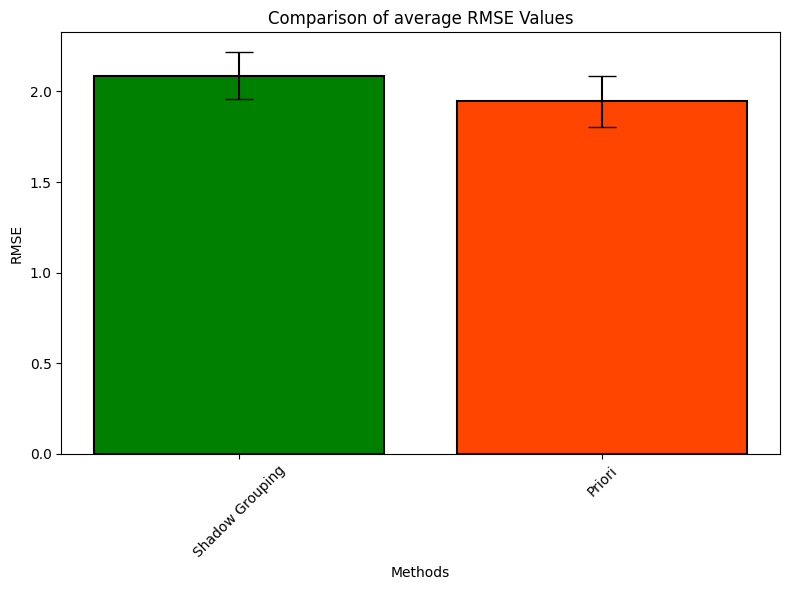

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['Shadow Grouping', 'Priori']
rmse_means = [np.mean(rmse_values_shadow), np.mean(rmse_values_priori)]
rmse_stds = [np.mean(rmse_stds_shadow), np.mean(rmse_stds_priori)]

plt.figure(figsize=(8, 6))
plt.bar(methods, rmse_means, yerr=rmse_stds, capsize=10, color=['green', '#FF4500'], edgecolor='black', linewidth=1.5)
plt.ylabel('RMSE')
plt.xlabel('Methods')
plt.title('Comparison of average RMSE Values')
plt.xticks(rotation=45)
plt.ylim(0, None)  # Ensure the y-axis starts at zero
plt.tight_layout()
plt.show()